In [1]:
import pathlib
import cv2
import numpy as np
import pandas as pd
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras import optimizers

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

c:\Users\Acer\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 2) MobileNetV2

In [2]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,

    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 4187 images belonging to 2 classes.


In [3]:
val_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

Found 1045 images belonging to 2 classes.


In [4]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [5]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.938425925925926), 1: np.float64(0.6738010943031864)}


In [7]:
checkpointer = ModelCheckpoint(
    filepath='MobileNetV2_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2, 
    factor=0.3,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [8]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
inputs = base_model.input

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)


x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x) 

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs, outputs)

In [10]:
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [12]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    class_weight=class_weights, 
    verbose=1
)

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6374 - loss: 0.5615 - precision: 0.9322 - recall: 0.5431
Epoch 1: val_loss improved from None to 0.26032, saving model to MobileNetV2_best_model.keras

Epoch 1: finished saving model to MobileNetV2_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.7476 - loss: 0.4269 - precision: 0.9642 - recall: 0.6852 - val_accuracy: 0.9263 - val_loss: 0.2603 - val_precision: 0.9581 - val_recall: 0.9420 - learning_rate: 1.0000e-04
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.8781 - loss: 0.2599 - precision: 0.9740 - recall: 0.8627
Epoch 2: val_loss improved from 0.26032 to 0.20178, saving model to MobileNetV2_best_model.keras

Epoch 2: finished saving model to MobileNetV2_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 962ms/step - accuracy: 0.8923 - loss: 0.2483 - precision: 0.9719 - recall: 0.8803 - val_accuracy: 0.9263 - val_loss: 0.2018 - val_precision: 0.9888 - val_recall: 0.9111 - l

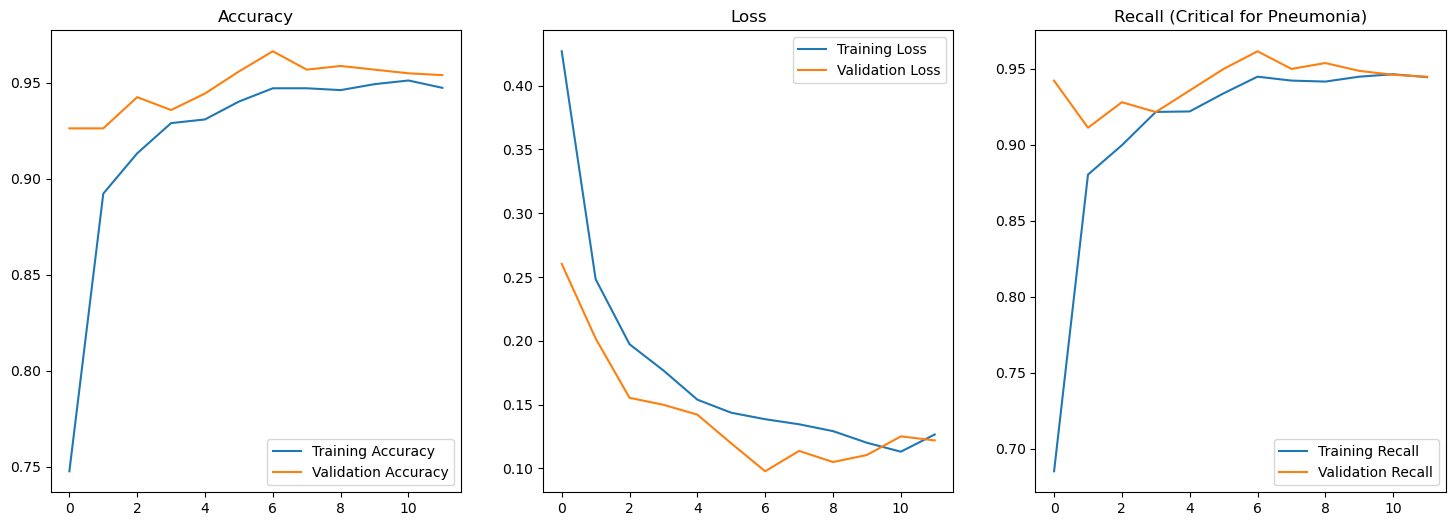

In [13]:
acc = mobilenet_history.history['accuracy']
val_acc = mobilenet_history.history['val_accuracy']

loss = mobilenet_history.history['loss']
val_loss = mobilenet_history.history['val_loss']

recall = mobilenet_history.history['recall']
val_recall = mobilenet_history.history['val_recall']

precision = mobilenet_history.history['precision']
val_precision = mobilenet_history.history['val_precision']

epochs_range = range(len(acc))

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 3, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend()
plt.title('Recall (Critical for Pneumonia)')

plt.show()

>The MobileNetV2 model shows strong generalization with high validation accuracy (~96%) and high recall (~95%), indicating effective pneumonia detection with minimal overfitting.

In [15]:
results = mobilenet_model.evaluate(test_generator)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8686 - loss: 0.2901 - precision: 0.8422 - recall: 0.9718
Test Loss: 0.2901259660720825
Test Accuracy: 0.8685897588729858
Test Precision: 0.8422222137451172
Test Recall: 0.971794843673706


>The model prioritizes high recall (~97%), ensuring minimal missed pneumonia cases, which is crucial in medical diagnosis despite a slight reduction in precision.

In [16]:
y_pred_prob = mobilenet_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step


In [17]:
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

In [18]:
y_true = test_generator.classes

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL       0.94      0.70      0.80       234
   PNEUMONIA       0.84      0.97      0.90       390

    accuracy                           0.87       624
   macro avg       0.89      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



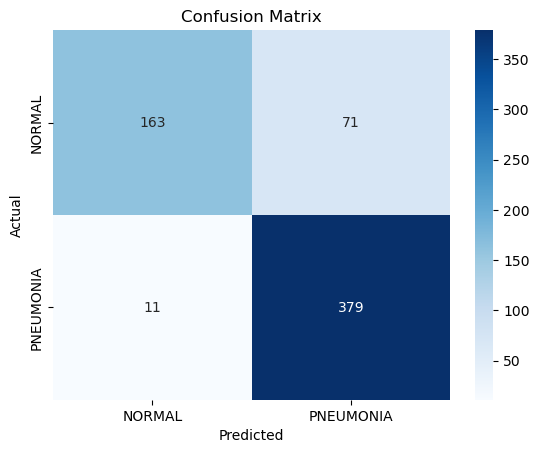

In [20]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model achieves very low false negatives (11), resulting in high recall (~97%), which is crucial in medical diagnosis. Although there are some false positives (71), this trade-off is acceptable as it prioritizes patient safety by minimizing missed pneumonia cases.

>The model achieves high recall with very few false negatives, ensuring most pneumonia cases are detected, while tolerating some false positives for safer diagnosis.

### Grad-CAM visualization

In [21]:
last_conv_layer_name = "Conv_1"

In [22]:
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

In [23]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]   # binary classification

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [24]:
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.show()

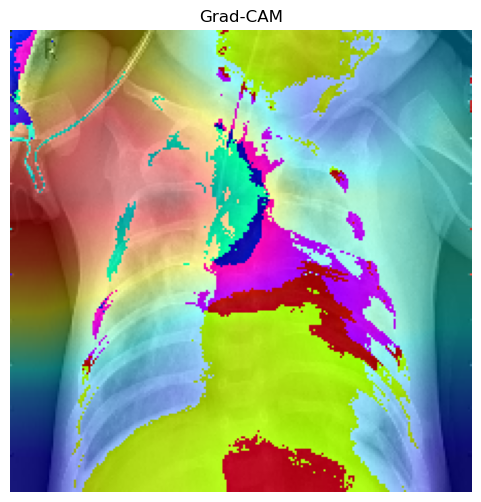

In [28]:
img_path1 = "Chest-Xray-2/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

img_array = get_img_array(img_path1)

heatmap = make_gradcam_heatmap(
    img_array,
    mobilenet_model,
    last_conv_layer_name="Conv_1"
)

display_gradcam(img_path1, heatmap)

* Strong activation in:
  - Central lung region
  - Lower lung zones
* Heatmap is focused (not random)

Model is detecting abnormal opacity regions (likely infection areas)

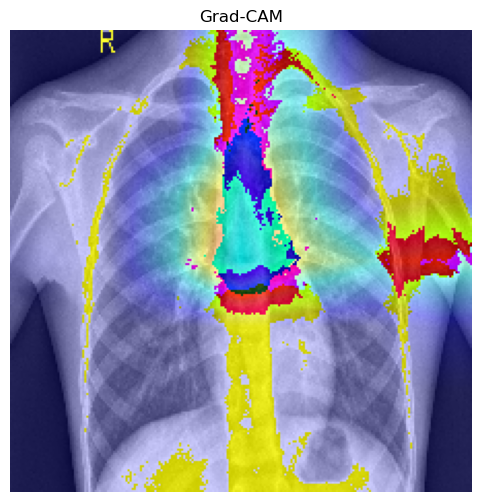

In [29]:
img_path2 = "Chest-Xray-2/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

img_array = get_img_array(img_path2)

heatmap = make_gradcam_heatmap(
    img_array,
    mobilenet_model,
    last_conv_layer_name="Conv_1"
)

display_gradcam(img_path2, heatmap)

* Heatmap is:
  - More spread out
  - Less intense
  - No strong localized hotspot

Model is NOT finding strong abnormal regions

---

>The model focuses on clinically relevant lung regions in pneumonia cases while showing diffuse attention in normal cases, indicating that it has learned meaningful spatial features.

>Grad-CAM visualizations show that the model correctly focuses on infected lung regions in pneumonia cases, while exhibiting diffuse attention in normal cases, validating its interpretability.

**How do you know your model is not a black box?**

- I used Grad-CAM to visualize model decisions. 
- The model focuses on lung regions with abnormalities in pneumonia cases and shows no strong focus for normal images, confirming that it learns clinically meaningful features.